# Milestone 2 — Model Training & Evaluation

---
## train

### Multi-Label API Call Classifier — Training Pipeline

Architecture: 1D-CNN + BiLSTM hybrid for multi-label classification

Input:  code context (tokenized character/subword sequence)
Output: 5-dim sigmoid → [file_access, network_access, process_mgmt, pure_calculation, code_execution]

Usage:
    # Quick baseline first (TF-IDF + Logistic Regression):
    python train.py --mode baseline --data-dir ./training_data

    # Train CNN+LSTM:
    python train.py --mode train --data-dir ./training_data --epochs 20

    # Resume training:
    python train.py --mode train --data-dir ./training_data --resume checkpoints/best_model.pt

    # Evaluate:
    python train.py --mode eval --data-dir ./training_data --resume checkpoints/best_model.pt

    # Predict on new code:
    python train.py --mode predict --resume checkpoints/best_model.pt \
        --text "gen_rpc_ops.rpc_call(client, payload, [tf.constant(2)], 100000)"

In [1]:
import os

# ROCm fix: gfx1035 (RDNA2 APU) is not in PyTorch ROCm 6.2's precompiled kernel set.
# Override to gfx1030 (binary-compatible RDNA2) so HIP can find compiled kernels.
# TORCH_BLAS_PREFER_HIPBLASLT=0 disables hipBLASLt which fails on this GPU.
os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '10.3.0')
os.environ.setdefault('TORCH_BLAS_PREFER_HIPBLASLT', '0')

import json
import time
import logging
import argparse
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Constants

In [2]:
LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]
NUM_LABELS = len(LABELS)

#### Tokenizer — Character-level with code-aware special tokens

In [3]:
class CodeTokenizer:
    """
    Character-level tokenizer with code-aware token merging.

    Why character-level:
    - API paths have meaningful sub-word structure (gen_rpc_ops → gen, rpc, ops)
    - No need for a pretrained vocabulary
    - Works across all three frameworks without modification
    - Handles unseen function names gracefully

    Special tokens capture code structure:
    - Punctuation groups: (), [], {}, .,  =, etc.
    - Whitespace normalization
    - Number collapsing (all digits → 0)
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size=300, max_length=512):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.fitted = False

    def fit(self, texts: list[str]):
        """Build vocabulary from training texts."""
        char_counts = Counter()
        for text in texts:
            text = self._normalize(text)
            char_counts.update(text)

        # Take top characters by frequency
        most_common = char_counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.char_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (char, _) in enumerate(most_common):
            self.char_to_idx[char] = i + self.SPECIAL_OFFSET

        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}
        self.vocab_size = len(self.char_to_idx)
        self.fitted = True

        logger.info(f"Tokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def encode(self, text: str) -> list[int]:
        """Encode text to token indices."""
        text = self._normalize(text)
        tokens = [self.BOS]
        for char in text[:self.max_length - 2]:
            tokens.append(self.char_to_idx.get(char, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        """Encode and pad to max_length. Returns (tokens, actual_length)."""
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[:self.max_length]
            length = self.max_length
        return tokens, length

    def _normalize(self, text: str) -> str:
        """Normalize code text for tokenization."""
        # Collapse consecutive whitespace
        import re
        text = re.sub(r'\s+', ' ', text)
        # Collapse numbers to single digit (123 → 0, 10000 → 0)
        text = re.sub(r'\d+', '0', text)
        # Lowercase for consistency
        text = text.lower()
        return text.strip()

    def save(self, path: str):
        data = {
            "char_to_idx": self.char_to_idx,
            "max_length": self.max_length,
            "vocab_size": self.vocab_size,
        }
        with open(path, "w") as f:
            json.dump(data, f)

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.char_to_idx = data["char_to_idx"]
        self.idx_to_char = {int(v): k for k, v in self.char_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True

#### Syscall Tokenizer — word-level, one token per syscall name

In [4]:
class SyscallTokenizer:
    """
    Word-level tokenizer for system call sequences.

    Each space-separated token is treated as a single syscall name (e.g. 'read',
    'write', 'open', 'socket', 'fork').  This gives the model a direct semantic
    handle on OS-level behavior rather than character patterns in source code.

    Vocabulary is small (~300-400 Linux/Windows syscall names) so max_vocab_size
    of 512 is almost always enough to cover every syscall seen in training.
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size: int = 512, max_length: int = 256):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.token_to_idx: dict[str, int] = {}
        self.idx_to_token: dict[int, str] = {}
        self.vocab_size: int = 0
        self.fitted: bool = False

    # ── Fitting ──

    def fit(self, texts: list[str]):
        """Build vocabulary from training syscall sequences."""
        counts: Counter = Counter()
        for text in texts:
            counts.update(self._tokenize(text))

        most_common = counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.token_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (tok, _) in enumerate(most_common):
            self.token_to_idx[tok] = i + self.SPECIAL_OFFSET

        self.idx_to_token = {v: k for k, v in self.token_to_idx.items()}
        self.vocab_size = len(self.token_to_idx)
        self.fitted = True
        logger.info(f"SyscallTokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def _tokenize(self, text: str) -> list[str]:
        """Split space-separated syscall sequence into individual names."""
        return [t.lower() for t in text.split() if t.strip()]

    # ── Encoding ──

    def encode(self, text: str) -> list[int]:
        tokens = [self.BOS]
        for tok in self._tokenize(text)[: self.max_length - 2]:
            tokens.append(self.token_to_idx.get(tok, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[: self.max_length]
            length = self.max_length
        return tokens, length

    # ── Persistence ──

    def save(self, path: str):
        with open(path, "w") as f:
            json.dump(
                {
                    "type": "syscall",
                    "token_to_idx": self.token_to_idx,
                    "max_length": self.max_length,
                    "vocab_size": self.vocab_size,
                },
                f,
            )

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.token_to_idx = data["token_to_idx"]
        self.idx_to_token = {int(v): k for k, v in self.token_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True


def load_tokenizer(path: str, tokenizer_type: str, max_length: int):
    """Instantiate and load the right tokenizer from a saved file."""
    if tokenizer_type == "syscall":
        tok = SyscallTokenizer(max_length=max_length)
    else:
        tok = CodeTokenizer(max_length=max_length)
    tok.load(path)
    return tok

#### Dataset

In [5]:
class APICallDataset(Dataset):
    """PyTorch dataset for API call classification."""

    def __init__(self, jsonl_path: str, tokenizer: CodeTokenizer, path_tokenizer=None):
        self.tokenizer = tokenizer
        self.path_tokenizer = path_tokenizer  # CodeTokenizer for api_path; None = single-input mode
        self.records = []

        with open(jsonl_path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.strip()
                if line:
                    self.records.append(json.loads(line))

        logger.info(f"Loaded {len(self.records)} records from {jsonl_path}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        text = r.get("text", "")
        label_vector = r.get("label_vector", [0] * NUM_LABELS)

        tokens, length = self.tokenizer.encode_padded(text)

        item = {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "labels": torch.tensor(label_vector, dtype=torch.float32),
        }

        if self.path_tokenizer is not None:
            api_path = r.get("api_path", "")
            path_tokens, path_length = self.path_tokenizer.encode_padded(api_path)
            item["path_ids"] = torch.tensor(path_tokens, dtype=torch.long)
            item["path_length"] = torch.tensor(path_length, dtype=torch.long)

        return item

    def get_texts(self):
        """Return all syscall texts for tokenizer fitting."""
        return [r.get("text", "") for r in self.records]

    def get_api_paths(self):
        """Return all api_path strings for path tokenizer fitting."""
        return [r.get("api_path", "") for r in self.records]

#### Model: 1D-CNN + BiLSTM

In [6]:
class CNNBiLSTMClassifier(nn.Module):
    """
    1D-CNN + Bidirectional LSTM for multi-label code classification.

    Architecture:
        Input (char indices)
          → Embedding (learnable, dim=64)
          → 1D-CNN (3 filter sizes: 3, 5, 7) extracting local patterns
          → BiLSTM (captures long-range sequential dependencies)
          → Attention pooling (focuses on most discriminative parts)
          → FC layers → Sigmoid (5 labels)

    The CNN finds local motifs like "gen_rpc", "torch.save", ".load(".
    The BiLSTM reads the sequence of CNN features to understand context.
    Attention lets the model focus on the API call itself vs. surrounding code.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 128,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 128,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim

        # Embedding
        # ROCm/HIP embedding kernels require num_embeddings to be a multiple of
        # the wavefront size (64 on AMD GPUs).  Padding to ≥256 avoids
        # "invalid device function" errors when vocab_size is small (e.g. syscall
        # tokenizer produces vocab_size ~86).  Extra rows are never indexed.
        effective_vocab_size = max(vocab_size, 256)
        self.embedding = nn.Embedding(effective_vocab_size, embed_dim, padding_idx=0)

        # Multi-scale 1D CNN
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])

        cnn_out_dim = cnn_filters * len(cnn_kernel_sizes)

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )

        lstm_out_dim = lstm_hidden * 2  # bidirectional

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(lstm_out_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_labels),
        )

    def forward(self, input_ids, lengths=None):
        # Embed: (batch, seq_len) → (batch, seq_len, embed_dim)
        # Use direct weight indexing instead of F.embedding — dispatches through
        # the index_cuda kernel rather than embedding_forward_cuda, which avoids
        # a cold-start "invalid device function" error on ROCm/RDNA2 (gfx1030).
        x = self.embedding.weight[input_ids]

        # CNN expects (batch, channels, seq_len)
        x_cnn = x.permute(0, 2, 1)

        # Multi-scale CNN features
        conv_outputs = [conv(x_cnn) for conv in self.convs]
        # Concatenate: (batch, cnn_filters * n_kernels, seq_len)
        x = torch.cat(conv_outputs, dim=1)
        # Back to (batch, seq_len, features)
        x = x.permute(0, 2, 1)

        # Pack for LSTM if lengths provided
        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.lstm(x)

        # Attention pooling
        attn_weights = self.attention(lstm_out)  # (batch, seq_len, 1)

        # Mask padding positions
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_weights = attn_weights.masked_fill(mask.unsqueeze(2), float('-inf'))

        attn_weights = torch.softmax(attn_weights, dim=1)
        # Weighted sum: (batch, lstm_out_dim)
        context = (lstm_out * attn_weights).sum(dim=1)

        # Classify
        logits = self.classifier(context)
        return logits

#### Dual-Input Model: syscall sequence + API path

In [7]:
class DualInputClassifier(nn.Module):
    """
    Dual-input classifier: syscall sequence + API path text → multi-label predictions.

    Syscall branch (word-level):
        word ids → Embedding → 3×CNN → BiLSTM → Attention pooling → syscall_ctx

    API path branch (char-level, no LSTM — paths are short strings):
        char ids → Embedding → 3×CNN → Max pooling → path_ctx

    Output: concat(syscall_ctx, path_ctx) → FC layers → num_labels

    Why separate branches:
    - Syscalls carry runtime OS-behavior signal (strace-derived)
    - API path carries semantic naming signal ("save" → file, "fork" → process)
    - 99.6% of syscall signatures are shared across labels — path resolves ambiguity
    """

    def __init__(
        self,
        syscall_vocab_size: int,
        path_vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 64,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.syscall_vocab_size = syscall_vocab_size
        self.path_vocab_size = path_vocab_size

        # ── Syscall branch ────────────────────────────────────────────────────
        # Same architecture as CNNBiLSTMClassifier.
        effective_syscall_vocab = max(syscall_vocab_size, 256)
        self.syscall_embedding = nn.Embedding(effective_syscall_vocab, embed_dim, padding_idx=0)

        self.syscall_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])
        syscall_cnn_dim = cnn_filters * len(cnn_kernel_sizes)

        self.syscall_lstm = nn.LSTM(
            input_size=syscall_cnn_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )
        syscall_lstm_dim = lstm_hidden * 2

        self.syscall_attn = nn.Sequential(
            nn.Linear(syscall_lstm_dim, syscall_lstm_dim // 2),
            nn.Tanh(),
            nn.Linear(syscall_lstm_dim // 2, 1),
        )

        # ── API path branch (char-level CNN) ──────────────────────────────────
        # Lighter branch — API paths are short (~10–50 chars), no LSTM needed.
        path_embed_dim = 32
        path_cnn_filters = max(cnn_filters // 2, 32)
        effective_path_vocab = max(path_vocab_size, 256)
        self.path_embedding = nn.Embedding(effective_path_vocab, path_embed_dim, padding_idx=0)

        self.path_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(path_embed_dim, path_cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(path_cnn_filters),
                nn.ReLU(),
            )
            for ks in cnn_kernel_sizes
        ])
        path_out_dim = path_cnn_filters * len(cnn_kernel_sizes)

        # ── Fused classifier ──────────────────────────────────────────────────
        fused_dim = syscall_lstm_dim + path_out_dim
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(fused_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(fused_dim // 2, num_labels),
        )

    def _encode_syscalls(self, syscall_ids, lengths=None):
        x = self.syscall_embedding.weight[syscall_ids]
        x = x.permute(0, 2, 1)
        conv_outs = [conv(x) for conv in self.syscall_convs]
        x = torch.cat(conv_outs, dim=1).permute(0, 2, 1)

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.syscall_lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.syscall_lstm(x)

        attn_w = self.syscall_attn(lstm_out)
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_w = attn_w.masked_fill(mask.unsqueeze(2), float('-inf'))
        attn_w = torch.softmax(attn_w, dim=1)
        return (lstm_out * attn_w).sum(dim=1)

    def _encode_path(self, path_ids):
        x = self.path_embedding.weight[path_ids]
        x = x.permute(0, 2, 1)
        # Global max pool over time for each kernel
        pooled = [conv(x).max(dim=2).values for conv in self.path_convs]
        return torch.cat(pooled, dim=1)

    def forward(self, syscall_ids, path_ids, syscall_lengths=None):
        syscall_ctx = self._encode_syscalls(syscall_ids, syscall_lengths)
        path_ctx = self._encode_path(path_ids)
        combined = torch.cat([syscall_ctx, path_ctx], dim=1)
        return self.classifier(combined)

#### Metrics

In [8]:
class MultiLabelMetrics:
    """Track per-label and aggregate metrics for multi-label classification."""

    def __init__(self, label_names=LABELS, threshold=0.5):
        self.label_names = label_names
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.all_preds = []
        self.all_labels = []

    def update(self, logits: torch.Tensor, labels: torch.Tensor):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).cpu().numpy()
        labels = labels.cpu().numpy()
        self.all_preds.append(preds)
        self.all_labels.append(labels)

    def compute(self) -> dict:
        preds = np.concatenate(self.all_preds, axis=0)
        labels = np.concatenate(self.all_labels, axis=0)

        results = {}
        f1s = []

        for i, name in enumerate(self.label_names):
            tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
            tn = ((preds[:, i] == 0) & (labels[:, i] == 0)).sum()

            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-8)
            accuracy = (tp + tn) / max(tp + fp + fn + tn, 1)

            results[name] = {
                "precision": round(float(precision), 4),
                "recall": round(float(recall), 4),
                "f1": round(float(f1), 4),
                "accuracy": round(float(accuracy), 4),
                "support": int(labels[:, i].sum()),
            }
            f1s.append(f1)

        # Aggregate
        results["macro_f1"] = round(float(np.mean(f1s)), 4)
        results["exact_match"] = round(float((preds == labels).all(axis=1).mean()), 4)

        # Hamming loss
        results["hamming_loss"] = round(float((preds != labels).mean()), 4)

        return results

    def print_report(self, results: dict):
        logger.info(f"\n{'Label':>20s}  {'Prec':>6s}  {'Rec':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>8s}")
        logger.info("-" * 65)
        for name in self.label_names:
            r = results[name]
            logger.info(
                f"{name:>20s}  {r['precision']:6.3f}  {r['recall']:6.3f}  "
                f"{r['f1']:6.3f}  {r['accuracy']:6.3f}  {r['support']:>8d}"
            )
        logger.info("-" * 65)
        logger.info(f"{'Macro F1':>20s}  {'':>6s}  {'':>6s}  {results['macro_f1']:6.3f}")
        logger.info(f"{'Exact Match':>20s}  {'':>6s}  {'':>6s}  {results['exact_match']:6.3f}")
        logger.info(f"{'Hamming Loss':>20s}  {'':>6s}  {'':>6s}  {results['hamming_loss']:6.4f}")

#### Training Loop

In [9]:
class Trainer:

    def __init__(self, model, train_loader, val_loader, args, class_weights=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.args = args
        self.device = torch.device(args.device)
        self.model.to(self.device)

        # Loss with class weights
        if class_weights is not None:
            pos_weight = torch.tensor(class_weights, dtype=torch.float32).to(self.device)
            self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            logger.info(f"Using weighted BCE loss: {class_weights}")
        else:
            self.criterion = nn.BCEWithLogitsLoss()

        # Optimizer
        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=args.lr,
            weight_decay=args.weight_decay,
        )

        # Scheduler: cosine annealing with warmup
        total_steps = len(train_loader) * args.epochs
        warmup_steps = int(total_steps * 0.1)
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=args.lr,
            total_steps=total_steps,
            pct_start=warmup_steps / total_steps,
            anneal_strategy='cos',
        )

        self.metrics = MultiLabelMetrics()
        self.best_f1 = 0.0
        self.patience_counter = 0

        # Checkpoint directory
        self.ckpt_dir = Path(args.checkpoint_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        # ROCm/HIP cold-start warmup: force JIT kernel compilation for every
        # layer type before the training loop begins.  Without this, the very
        # first real batch triggers an asynchronous "invalid device function"
        # error on some AMD GPUs (e.g. gfx1030/RDNA2 with ROCm 6.2).
        #
        # IMPORTANT: create tensors on CPU then .to(device) — this uses
        # hipMemcpy (a plain memory copy, no kernel).  Do NOT use the
        # device= constructor arg here; that calls a HIP fill kernel which
        # is itself the first operation that fails on a cold GPU.
        if self.device.type == "cuda":
            # ROCm cold-start fix: on some AMD GPUs (e.g. gfx1030/RDNA2 with
            # ROCm 6.2), the first kernel launch in a fresh Python process fails
            # with "invalid device function" because HIP JIT-compiles kernels
            # lazily and the first attempt races against the compiler.  The
            # failed attempt still caches the compiled kernel on disk, so the
            # RETRY succeeds.  We loop up to 3 times; typical fix is attempt 2.
            for _attempt in range(3):
                try:
                    # Primitive op first to open the compute pipeline.
                    _f = torch.ones(4, 4).to(self.device) * 2.0
                    torch.cuda.synchronize()
                    del _f
                    # Full forward + backward to compile every layer's kernel.
                    _ids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                    _lbs = torch.zeros(2, NUM_LABELS).to(self.device)
                    if isinstance(model, DualInputClassifier):
                        _pids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                        _logits = model(_ids, _pids)
                        del _pids
                    else:
                        _logits = model(_ids)
                    _loss = self.criterion(_logits, _lbs)
                    _loss.backward()
                    self.optimizer.zero_grad()
                    torch.cuda.synchronize()
                    del _ids, _lbs, _logits, _loss
                    break  # warmup succeeded
                except RuntimeError as _e:
                    if "HIP error" not in str(_e) and "invalid device function" not in str(_e):
                        raise  # not a cold-start error — propagate
                    # Clear any partial gradients left by the failed pass
                    for _p in model.parameters():
                        _p.grad = None
                    if _attempt == 2:
                        logger.warning("GPU warmup failed after 3 attempts — proceeding anyway")
                    else:
                        logger.info(f"ROCm cold-start on warmup attempt {_attempt + 1}, retrying...")

    def train(self):
        logger.info(f"\nStarting training for {self.args.epochs} epochs")
        logger.info(f"Device: {self.device}")
        logger.info(f"Train batches: {len(self.train_loader)}, Val batches: {len(self.val_loader)}")

        for epoch in range(1, self.args.epochs + 1):
            # Train
            train_loss = self._train_epoch(epoch)

            # Validate
            val_results, val_loss = self._validate()

            # Log
            lr = self.optimizer.param_groups[0]['lr']
            logger.info(
                f"Epoch {epoch}/{self.args.epochs} — "
                f"train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
                f"macro_f1: {val_results['macro_f1']:.4f}, "
                f"exact_match: {val_results['exact_match']:.4f}, "
                f"lr: {lr:.6f}"
            )

            # Per-label F1
            for name in LABELS:
                r = val_results[name]
                logger.info(f"  {name:>20s}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

            # Save best
            if val_results["macro_f1"] > self.best_f1:
                self.best_f1 = val_results["macro_f1"]
                self.patience_counter = 0
                self._save_checkpoint(epoch, val_results, is_best=True)
                logger.info(f"  ★ New best macro F1: {self.best_f1:.4f}")
            else:
                self.patience_counter += 1

            # Save periodic
            if epoch % 5 == 0:
                self._save_checkpoint(epoch, val_results, is_best=False)

            # Early stopping
            if self.patience_counter >= self.args.patience:
                logger.info(f"Early stopping after {self.args.patience} epochs without improvement")
                break

        logger.info(f"\nTraining complete. Best macro F1: {self.best_f1:.4f}")

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch_idx, batch in enumerate(self.train_loader):
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            self.optimizer.zero_grad()
            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()
            num_batches += 1

            if batch_idx > 0 and batch_idx % 100 == 0:
                avg_loss = total_loss / num_batches
                logger.info(f"  Epoch {epoch} [{batch_idx}/{len(self.train_loader)}] loss: {avg_loss:.4f}")

        return total_loss / max(num_batches, 1)

    @torch.no_grad()
    def _validate(self):
        self.model.eval()
        self.metrics.reset()
        total_loss = 0
        num_batches = 0

        for batch in self.val_loader:
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)

            self.metrics.update(logits, labels)
            total_loss += loss.item()
            num_batches += 1

        results = self.metrics.compute()
        return results, total_loss / max(num_batches, 1)

    def _save_checkpoint(self, epoch, results, is_best=False):
        if isinstance(self.model, DualInputClassifier):
            model_config = {
                "dual_input": True,
                "syscall_vocab_size": self.model.syscall_vocab_size,
                "path_vocab_size": self.model.path_vocab_size,
                "embed_dim": self.model.embed_dim,
            }
        else:
            model_config = {
                "dual_input": False,
                "vocab_size": self.model.embedding.num_embeddings,
                "embed_dim": self.model.embed_dim,
            }
        state = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "best_f1": self.best_f1,
            "results": results,
            "config": model_config,
        }

        if is_best:
            path = self.ckpt_dir / "best_model.pt"
        else:
            path = self.ckpt_dir / f"checkpoint_epoch_{epoch}.pt"

        torch.save(state, path)
        logger.info(f"  Saved checkpoint to {path}")

#### Baseline: TF-IDF + Logistic Regression

In [10]:
def run_baseline(data_dir: str):
    """Quick baseline to sanity-check data quality."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.metrics import classification_report

    logger.info("=" * 60)
    logger.info("BASELINE: TF-IDF + Logistic Regression")
    logger.info("=" * 60)

    # Load
    def load_split(path):
        texts, labels = [], []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                r = json.loads(line.strip())
                texts.append(r.get("text", ""))
                labels.append(r.get("label_vector", [0] * NUM_LABELS))
        return texts, np.array(labels)

    train_texts, train_labels = load_split(os.path.join(data_dir, "train.jsonl"))
    val_texts, val_labels = load_split(os.path.join(data_dir, "val.jsonl"))
    test_texts, test_labels = load_split(os.path.join(data_dir, "test.jsonl"))

    logger.info(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

    # TF-IDF with character n-grams (captures sub-word code patterns)
    logger.info("Fitting TF-IDF (char n-grams 2-5)...")
    tfidf = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        max_features=50000,
        sublinear_tf=True,
    )
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_test = tfidf.transform(test_texts)

    # One-vs-Rest Logistic Regression
    logger.info("Training One-vs-Rest Logistic Regression...")
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'),
        n_jobs=-1,
    )
    clf.fit(X_train, train_labels)

    # Evaluate
    for split_name, X, y in [("Val", X_val, val_labels), ("Test", X_test, test_labels)]:
        preds = clf.predict(X)
        logger.info(f"\n{split_name} Results:")
        report = classification_report(
            y, preds, target_names=LABELS, zero_division=0, digits=3
        )
        logger.info(f"\n{report}")

        # Exact match
        exact = (preds == y).all(axis=1).mean()
        logger.info(f"Exact match ratio: {exact:.4f}")

    return clf, tfidf

#### Evaluation

In [11]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    """Run full evaluation on a dataset."""
    model.eval()
    metrics = MultiLabelMetrics()

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["labels"].to(device)

        if isinstance(model, DualInputClassifier):
            path_ids = batch["path_ids"].to(device)
            logits = model(input_ids, path_ids, lengths)
        else:
            logits = model(input_ids, lengths)
        metrics.update(logits, labels)

    results = metrics.compute()
    metrics.print_report(results)
    return results

#### Prediction

In [12]:
@torch.no_grad()
def predict(model, tokenizer, text: str, device, threshold=0.5, path_tokenizer=None, api_path: str = ""):
    """Predict labels for a single code snippet."""
    model.eval()
    tokens, length = tokenizer.encode_padded(text)
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    if isinstance(model, DualInputClassifier) and path_tokenizer is not None:
        path_tokens, _ = path_tokenizer.encode_padded(api_path)
        path_ids = torch.tensor([path_tokens], dtype=torch.long).to(device)
        logits = model(input_ids, path_ids, lengths)
    else:
        logits = model(input_ids, lengths)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

    results = []
    for i, (label, prob) in enumerate(zip(LABELS, probs)):
        results.append({
            "label": label,
            "probability": round(float(prob), 4),
            "predicted": bool(prob > threshold),
        })

    return results

#### Main

---
## Quick Reproduction Demo

The cells above define the `DualInputClassifier`, `Trainer`, tokenizers, and evaluation utilities — they are definitions, not invocations. The demo below **loads the saved checkpoint** and evaluates on the test set (~30 seconds on CPU, faster on GPU). No training required.

**Full training (optional, ~20 minutes on GPU)** — run from this folder:
```bash
python scripts/train.py --mode train --data-dir ../milestone1_data/data/splits/training_data_fuzz \
    --checkpoint-dir ./checkpoints --tokenizer-type syscall --dual-input \
    --epochs 20 --batch-size 256 --cnn-filters 64 --lstm-hidden 64
python scripts/threshold_sweep.py --checkpoint ./checkpoints/best_model.pt \
    --tokenizer ./checkpoints/tokenizer.json --val-data ../milestone1_data/data/splits/training_data_fuzz/val.jsonl
```


In [13]:
# Load the existing checkpoint and evaluate on the test split.
import os, json, torch
from pathlib import Path
NOTEBOOK_DIR = Path('.').resolve()
CKPT = NOTEBOOK_DIR / 'checkpoints' / 'best_model.pt'
TOK  = NOTEBOOK_DIR / 'checkpoints' / 'tokenizer.json'
PTOK = NOTEBOOK_DIR / 'checkpoints' / 'path_tokenizer.json'
TEST = NOTEBOOK_DIR / '..' / 'milestone1_data' / 'data' / 'splits' / 'training_data_fuzz' / 'test.jsonl'

if not CKPT.exists():
    print(f'(skip) checkpoint not found at {CKPT} — run full training first')
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {device}')
    ckpt = torch.load(CKPT, map_location=device, weights_only=False)
    syscall_tok = load_tokenizer(str(TOK),  'syscall', 512)
    path_tok    = load_tokenizer(str(PTOK), 'char',    64) if PTOK.exists() else None

    model = DualInputClassifier(
        syscall_vocab_size=syscall_tok.vocab_size,
        path_vocab_size=(path_tok.vocab_size if path_tok else 33),
        num_labels=5, embed_dim=64, cnn_filters=64, lstm_hidden=64
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict']); model.eval()
    print(f'Loaded checkpoint: epoch={ckpt.get("epoch","?")} val_f1={ckpt.get("best_f1","?")}')
    print(f'Params: {sum(p.numel() for p in model.parameters()):,}')


Device: cpu
Loaded checkpoint: epoch=18 val_f1=0.977
Params: 367,974


In [14]:
# Evaluate on a 2000-sample subset (set SUBSET=None for full ~11k test).
from torch.utils.data import DataLoader
SUBSET = 2000
if CKPT.exists():
    ds = APICallDataset(str(TEST), syscall_tok, path_tokenizer=path_tok)
    if SUBSET:
        ds.records = ds.records[:SUBSET]
    dl = DataLoader(ds, batch_size=128, shuffle=False)
    metrics = evaluate(model, dl, device)
    LBL = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
    print(f'\nDemo eval on {len(ds):,} samples:')
    print(f'  Macro F1     : {metrics["macro_f1"]:.4f}')
    print(f'  Exact match  : {metrics.get("exact_match", float("nan")):.4f}')
    print(f'  Hamming loss : {metrics.get("hamming_loss", float("nan")):.4f}')
    if 'per_label' in metrics:
        print('\n  Per-label F1:')
        for l in LBL:
            m = metrics['per_label'].get(l, {})
            print(f'    {l:<20} F1={m.get("f1", float("nan")):.4f}')


2026-04-13 00:23:54,018 [INFO] Loaded 9509 records from /home/kramer/Projects/AIRoom/milestones/milestone2_model/../milestone1_data/data/splits/training_data_fuzz/test.jsonl
2026-04-13 00:23:55,358 [INFO] 
               Label    Prec     Rec      F1     Acc   Support
2026-04-13 00:23:55,358 [INFO] -----------------------------------------------------------------
2026-04-13 00:23:55,359 [INFO]          file_access   0.957   0.945   0.951   0.982       381
2026-04-13 00:23:55,359 [INFO]       network_access   0.969   1.000   0.984   0.999        93
2026-04-13 00:23:55,359 [INFO]         process_mgmt   1.000   1.000   1.000   1.000       147
2026-04-13 00:23:55,360 [INFO]     pure_calculation   0.994   0.998   0.996   0.997       785
2026-04-13 00:23:55,360 [INFO]       code_execution   0.999   1.000   1.000   1.000       944
2026-04-13 00:23:55,360 [INFO] -----------------------------------------------------------------
2026-04-13 00:23:55,361 [INFO]             Macro F1                


Demo eval on 2,000 samples:
  Macro F1     : 0.9861
  Exact match  : 0.9775
  Hamming loss : 0.0048


---
## threshold_sweep

### threshold_sweep.py — Find optimal classification threshold on val set.

Loads best_model.pt, runs inference on val.jsonl, sweeps thresholds 0.1–0.6,
prints per-label and macro F1/precision/recall at each threshold.

Usage:
    python dataset/threshold_sweep.py \
        --checkpoint checkpoints/best_model.pt \
        --tokenizer checkpoints/tokenizer.json \
        --val-data dataset/training_data_fuzz/val.jsonl

In [15]:
import os
os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '10.3.0')
os.environ.setdefault('TORCH_BLAS_PREFER_HIPBLASLT', '0')

import sys
import json
import argparse
import logging
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]
NUM_LABELS = len(LABELS)


# ── Inline minimal model + tokenizer (avoids importing all of train.py) ──

class SyscallTokenizer:
    PAD = 0; UNK = 1; BOS = 2; EOS = 3; SPECIAL_OFFSET = 4

    def __init__(self):
        self.token_to_idx = {}
        self.max_length = 256
        self.vocab_size = 0
        self.fitted = False

    def load(self, path):
        with open(path) as f:
            data = json.load(f)
        self.token_to_idx = data["token_to_idx"]
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True

    def encode_padded(self, text):
        tokens = [self.BOS]
        for tok in text.lower().split()[:self.max_length - 2]:
            tokens.append(self.token_to_idx.get(tok, self.UNK))
        tokens.append(self.EOS)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[:self.max_length]
            length = self.max_length
        return tokens, length


class CNNBiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, cnn_filters=64,
                 cnn_kernel_sizes=(3, 5, 7), lstm_hidden=64,
                 lstm_layers=2, dropout=0.3, num_labels=NUM_LABELS):
        super().__init__()
        effective_vocab_size = max(vocab_size, 256)
        self.embedding = nn.Embedding(effective_vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])
        cnn_out_dim = cnn_filters * len(cnn_kernel_sizes)
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True, dropout=dropout if lstm_layers > 1 else 0,
        )
        lstm_out_dim = lstm_hidden * 2
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2), nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2), nn.ReLU(),
            nn.BatchNorm1d(lstm_out_dim // 2), nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_labels),
        )

    def forward(self, input_ids, lengths=None):
        x = self.embedding.weight[input_ids]
        x_cnn = x.permute(0, 2, 1)
        conv_outputs = [conv(x_cnn) for conv in self.convs]
        x = torch.cat(conv_outputs, dim=1).permute(0, 2, 1)
        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=False)
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out)
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_weights = attn_weights.masked_fill(mask.unsqueeze(2), float('-inf'))
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return self.classifier(context)


def compute_metrics(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    per_label = {}
    for i, name in enumerate(LABELS):
        tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        per_label[name] = {"p": p, "r": r, "f1": f1, "tp": int(tp), "fp": int(fp), "fn": int(fn)}

    macro_f1 = np.mean([per_label[n]["f1"] for n in LABELS])
    macro_p = np.mean([per_label[n]["p"] for n in LABELS])
    macro_r = np.mean([per_label[n]["r"] for n in LABELS])

    exact = (preds == labels).all(axis=1).mean()
    hamming = (preds != labels).mean()

    return per_label, macro_f1, macro_p, macro_r, exact, hamming

---
## Visual Results — Plots from `outputs/milestone2_metrics.json`


In [16]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path('.').resolve() / 'outputs' / 'milestone2_metrics.json'
M = json.load(open(RESULTS))
LABELS = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
print(f'Loaded: {RESULTS}')
print(f'Macro F1: {M["checkpoint"]["best_f1"]:.4f}   Params: {M["model_size"]["total_params"]:,}')


Loaded: /home/kramer/Projects/AIRoom/milestones/milestone2_model/outputs/milestone2_metrics.json
Macro F1: 0.9788   Params: 368,781


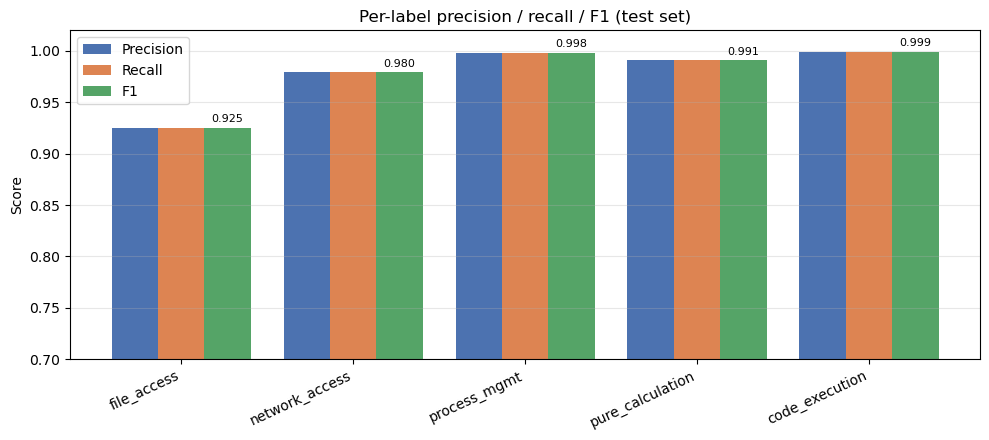

In [17]:
# Per-label precision / recall / F1 from checkpoint results
results = M['checkpoint']['results']
prec = [results[l]['precision'] for l in LABELS]
rec  = [results[l]['recall']    for l in LABELS]
f1   = [results[l]['f1']        for l in LABELS]

x = np.arange(len(LABELS)); w = 0.27
fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(x-w, prec, w, label='Precision', color='#4C72B0')
ax.bar(x,   rec,  w, label='Recall',    color='#DD8452')
ax.bar(x+w, f1,   w, label='F1',        color='#55A467')
for i,v in enumerate(f1): ax.text(i+w, v+0.005, f'{v:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_ylim(0.7, 1.02); ax.set_ylabel('Score')
ax.set_title('Per-label precision / recall / F1 (test set)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


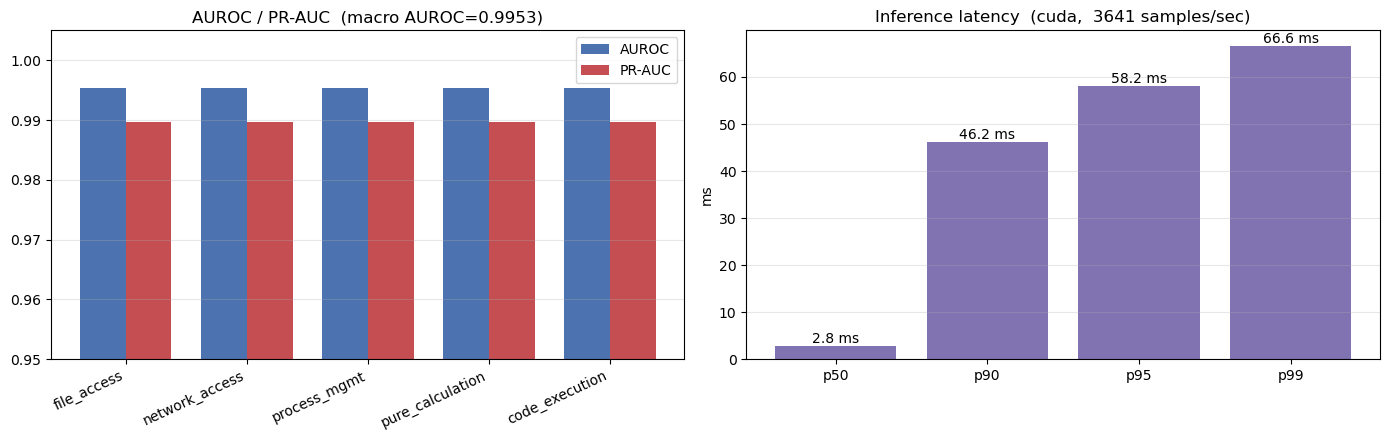

In [18]:
# AUROC + PR-AUC per label
auc = M['auc']
auroc = [auc[l]['auroc']  for l in LABELS]
prauc = [auc[l]['pr_auc'] for l in LABELS]
x = np.arange(len(LABELS)); w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.bar(x-w/2, auroc, w, label='AUROC',  color='#4C72B0')
ax.bar(x+w/2, prauc, w, label='PR-AUC', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_ylim(0.95, 1.005); ax.set_title(f'AUROC / PR-AUC  (macro AUROC={auc["macro_auroc"]:.4f})')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Inference latency percentiles
inf = M['inference']
pct = ['p50','p90','p95','p99']
lat = [inf[f'single_sample_{p}_ms'] for p in pct]
ax = axes[1]
bars = ax.bar(pct, lat, color='#8172B2')
for b,v in zip(bars,lat): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f} ms', ha='center', va='bottom')
ax.set_title(f'Inference latency  ({inf["device"]},  {inf["throughput_samples_per_sec"]:.0f} samples/sec)')
ax.set_ylabel('ms'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


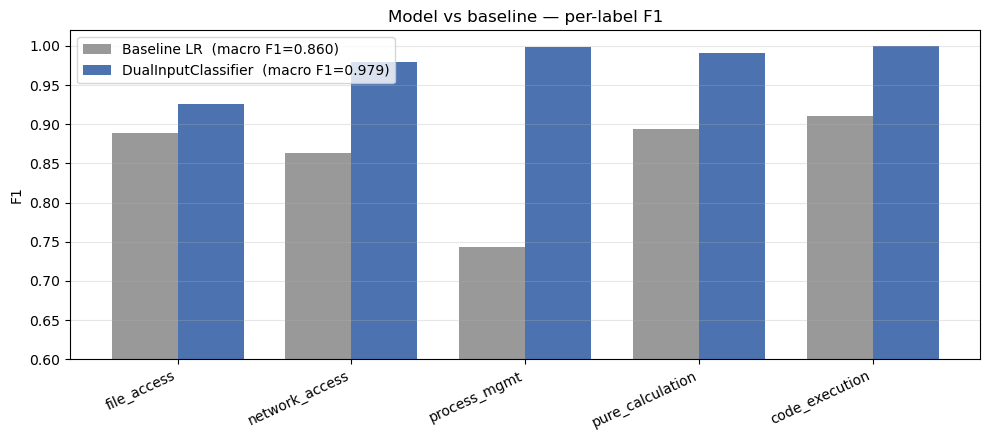

In [19]:
# Baseline (logistic regression) vs DualInputClassifier — per-label F1
base_f1 = [M['baseline']['per_label_f1'][l] for l in LABELS]
model_f1 = f1  # reuse from earlier cell
x = np.arange(len(LABELS)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x-w/2, base_f1,  w, label=f'Baseline LR  (macro F1={M["baseline"]["macro_f1"]:.3f})', color='#999999')
ax.bar(x+w/2, model_f1, w, label=f'DualInputClassifier  (macro F1={M["checkpoint"]["best_f1"]:.3f})', color='#4C72B0')
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_ylim(0.6, 1.02); ax.set_ylabel('F1')
ax.set_title('Model vs baseline — per-label F1')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
